# Commodity Price Forecasting — Exploratory Data Analysis (EDA)
### Project by Rayan Rawat

This notebook covers:
- Loading cleaned data from Notebook 1
- Price distribution analysis
- Returns and volatility analysis
- Seasonal pattern detection
- Cross-commodity correlation analysis
- Stationarity testing (ADF/KPSS)

**Goal:** Understand price behavior deeply before building any forecasting model.
**Data:** Daily OHLCV data for BRENT, WTI, Natural Gas, RBOB, Heating Oil (2010–2026)

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1 — Load Cleaned Data
We load the 5 CSV files saved in Notebook 1.
From this point forward we never touch Yahoo Finance again —
all analysis runs on these local files.

In [3]:
commodities = ['BRENT', 'WTI', 'NATURAL_GAS', 'RBOB', 'HEATING_OIL']
data = {}

for name in commodities:
    filepath = f'data/{name}.csv'
    df = pd.read_csv(filepath, index_col='Date', parse_dates=True)
    df.index.name = 'Date'
    data[name] = df
    print(f"Loaded {name}: {df.shape[0]} rows | {df.index[0].date()} to {df.index[-1].date()}")

print("\nAll commodities loaded successfully!")

Loaded BRENT: 4186 rows | 2010-01-04 to 2026-10-08
Loaded WTI: 4217 rows | 2010-01-04 to 2026-10-08
Loaded NATURAL_GAS: 4218 rows | 2010-01-04 to 2026-10-08
Loaded RBOB: 4217 rows | 2010-01-04 to 2026-10-08
Loaded HEATING_OIL: 4217 rows | 2010-01-04 to 2026-10-08

All commodities loaded successfully!


## Part 1 — Price Distribution Analysis
We examine the statistical distribution of closing prices for each commodity.
This tells us the price range, average, and whether prices are normally distributed.

In [4]:
print("=" * 60)
print("CLOSING PRICE STATISTICS (2010-2026)")
print("=" * 60)

for name in commodities:
    df = data[name]
    close = df['Close']
    
    print(f"\n{name}")
    print(f"  Mean price    : ${close.mean():.2f}")
    print(f"  Median price  : ${close.median():.2f}")
    print(f"  Std deviation : ${close.std():.2f}")
    print(f"  Min price     : ${close.min():.2f}")
    print(f"  Max price     : ${close.max():.2f}")
    print(f"  Current price : ${close.iloc[-1]:.2f}")

CLOSING PRICE STATISTICS (2010-2026)

BRENT
  Mean price    : $78.02
  Median price  : $75.92
  Std deviation : $23.28
  Min price     : $19.33
  Max price     : $127.98
  Current price : $104.06

WTI
  Mean price    : $72.11
  Median price  : $72.09
  Std deviation : $20.70
  Min price     : $-37.63
  Max price     : $123.70
  Current price : $91.62

NATURAL_GAS
  Mean price    : $3.37
  Median price  : $3.03
  Std deviation : $1.21
  Min price     : $1.48
  Max price     : $9.68
  Current price : $3.24

RBOB
  Mean price    : $2.21
  Median price  : $2.13
  Std deviation : $0.63
  Min price     : $0.41
  Max price     : $4.28
  Current price : $3.16

HEATING_OIL
  Mean price    : $2.38
  Median price  : $2.28
  Std deviation : $0.75
  Min price     : $0.61
  Max price     : $5.26
  Current price : $4.81


## Price Distribution — Visual Analysis
Histogram + KDE plots for each commodity.
Note: WTI shows negative prices in April 2020 (historic contango blowout).

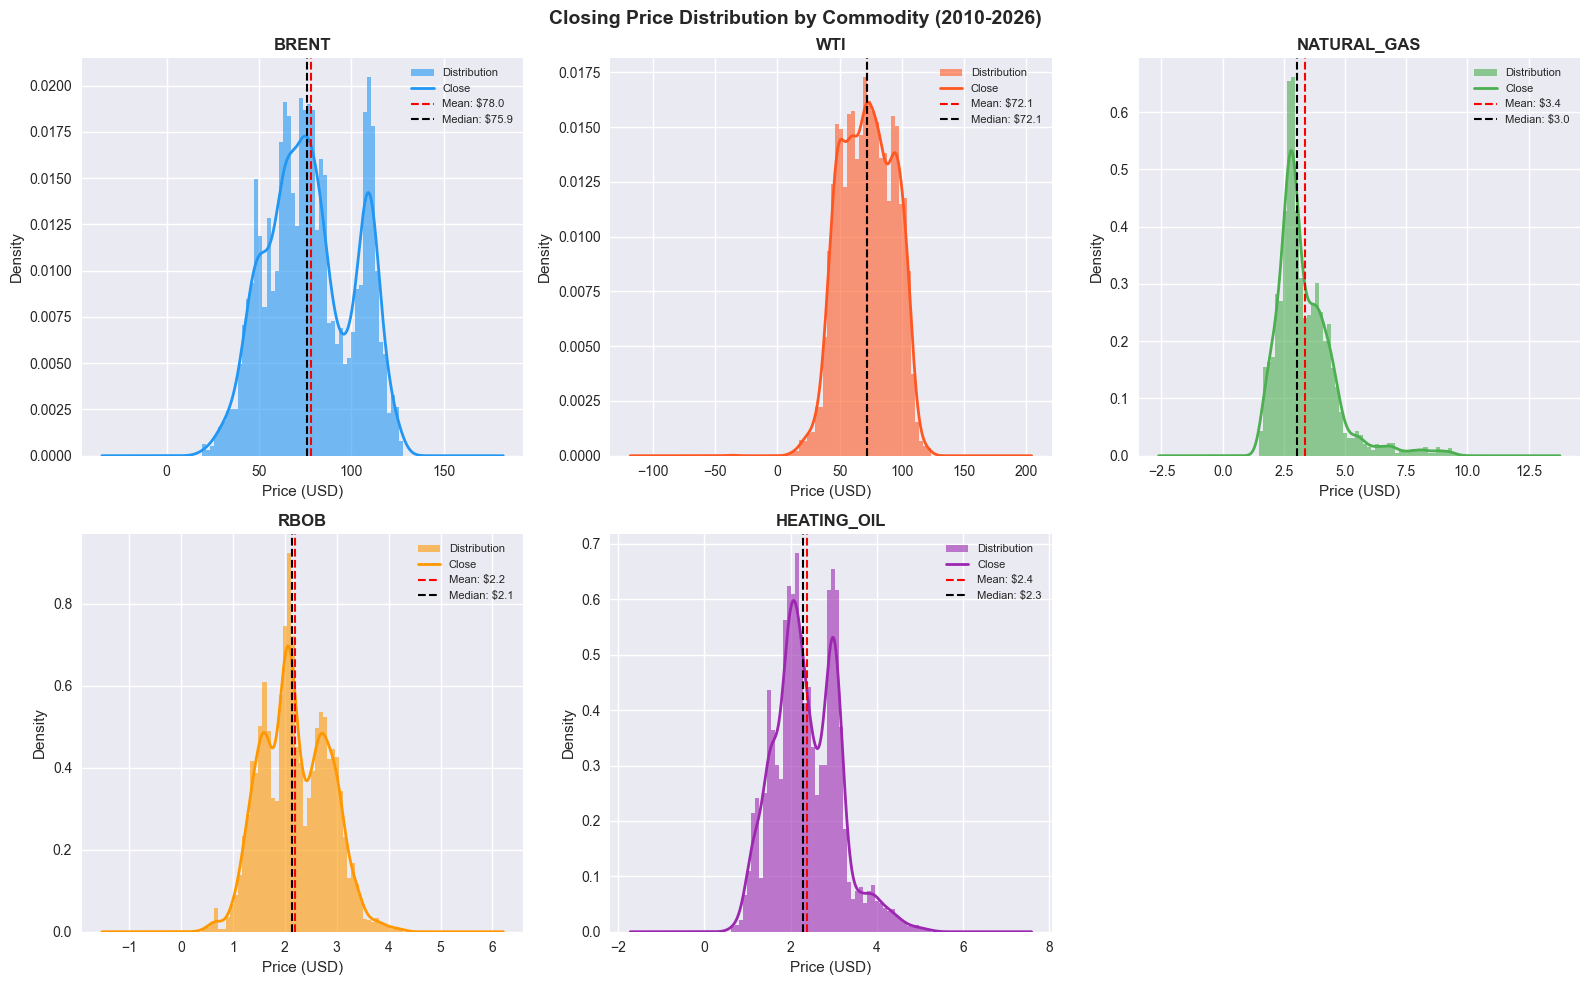

Chart saved!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Closing Price Distribution by Commodity (2010-2026)', 
             fontsize=14, fontweight='bold')

axes = axes.flatten()
colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

for idx, (name, color) in enumerate(zip(commodities, colors)):
    ax = axes[idx]
    close = data[name]['Close']
    
    # Plot histogram + KDE
    ax.hist(close, bins=50, color=color, alpha=0.6, 
            density=True, label='Distribution')
    close.plot.kde(ax=ax, color=color, linewidth=2)
    
    # Add mean and median lines
    ax.axvline(close.mean(), color='red', linestyle='--', 
               linewidth=1.5, label=f'Mean: ${close.mean():.1f}')
    ax.axvline(close.median(), color='black', linestyle='--', 
               linewidth=1.5, label=f'Median: ${close.median():.1f}')
    
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Hide the 6th empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('data/price_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Part 2 — Returns Analysis
We calculate daily log returns for each commodity.
Log returns are preferred in finance because they are:
- Additive over time
- More normally distributed than simple returns
- Comparable across commodities with different price levels

In [6]:
for name in commodities:
    df = data[name]
    # np.log gives us natural log
    # shift(1) means "yesterday's price"
    # so log(today/yesterday) = log(today) - log(yesterday)
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    data[name] = df

# Print return statistics
print("=" * 60)
print("DAILY LOG RETURN STATISTICS")
print("=" * 60)

for name in commodities:
    returns = data[name]['Log_Return'].dropna()
    print(f"\n{name}")
    print(f"  Mean daily return : {returns.mean()*100:.4f}%")
    print(f"  Std deviation     : {returns.std()*100:.4f}%")
    print(f"  Best day ever     : {returns.max()*100:.2f}%")
    print(f"  Worst day ever    : {returns.min()*100:.2f}%")

DAILY LOG RETURN STATISTICS

BRENT
  Mean daily return : 0.0062%
  Std deviation     : 2.3449%
  Best day ever     : 19.08%
  Worst day ever    : -27.98%

WTI
  Mean daily return : 0.0171%
  Std deviation     : 2.6210%
  Best day ever     : 31.96%
  Worst day ever    : -28.22%

NATURAL_GAS
  Mean daily return : -0.0142%
  Std deviation     : 3.8135%
  Best day ever     : 38.17%
  Worst day ever    : -64.40%

RBOB
  Mean daily return : 0.0096%
  Std deviation     : 2.6003%
  Best day ever     : 22.40%
  Worst day ever    : -38.54%

HEATING_OIL
  Mean daily return : 0.0187%
  Std deviation     : 2.2916%
  Best day ever     : 12.36%
  Worst day ever    : -24.75%


## Returns Distribution — Visual Analysis
Daily log returns plotted as histograms.
A normal distribution (bell curve) centered at zero means random walk behavior.
Fat tails indicate extreme moves happen more often than normal distribution predicts.

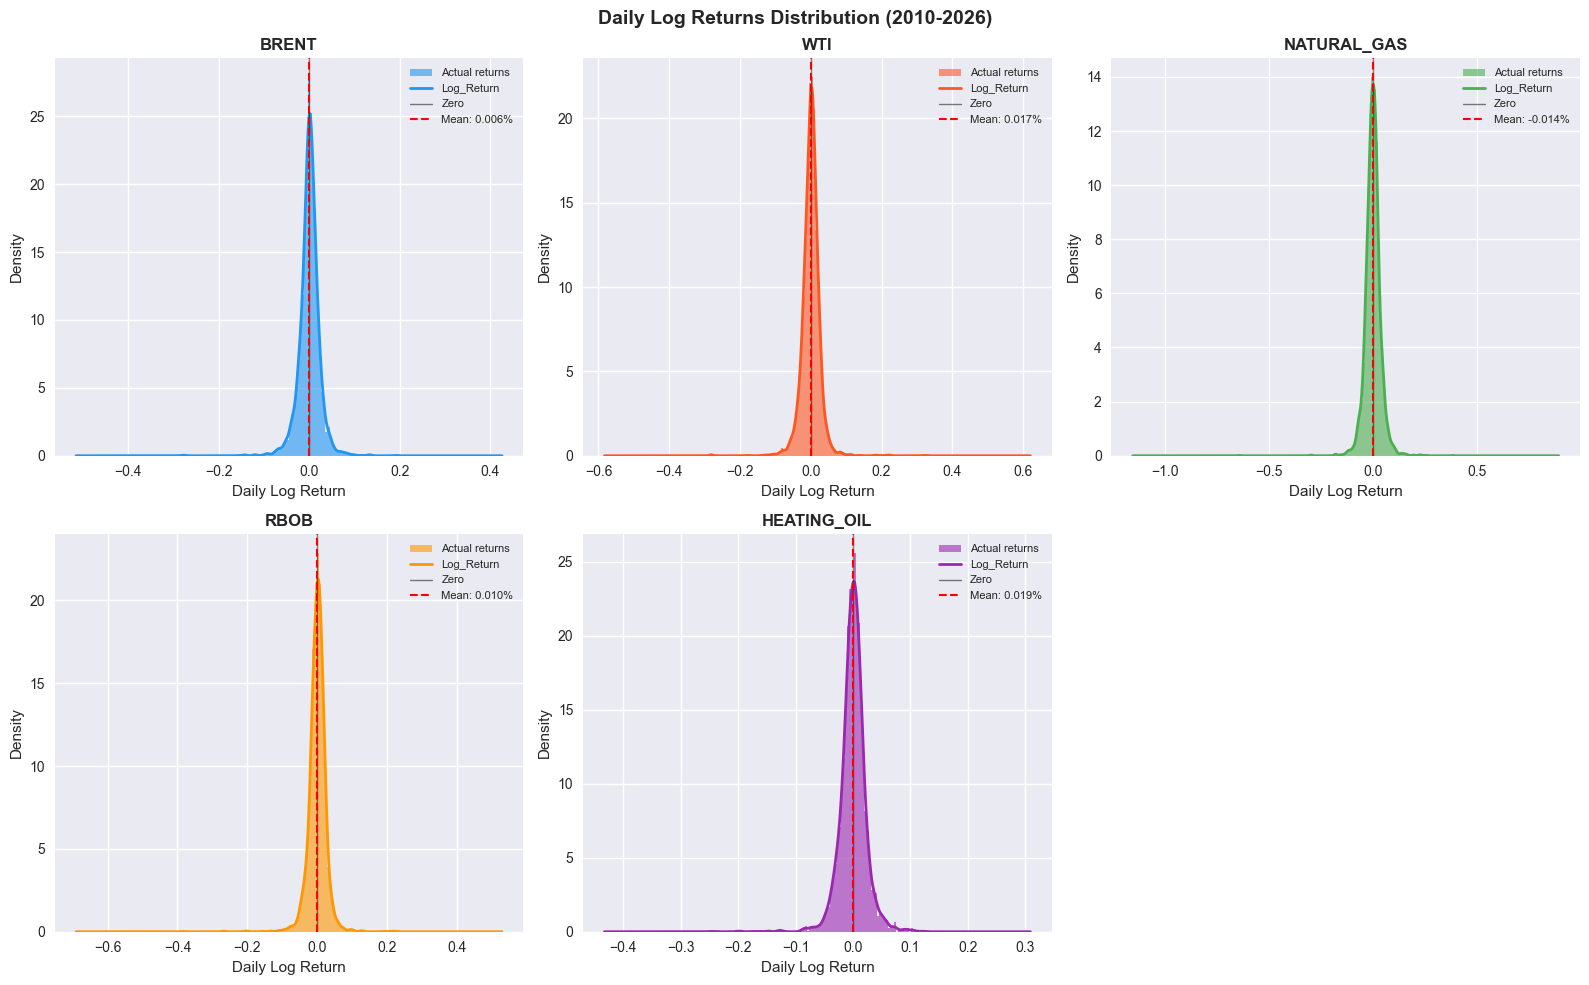

Chart saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Daily Log Returns Distribution (2010-2026)',
             fontsize=14, fontweight='bold')

axes = axes.flatten()
colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

for idx, (name, color) in enumerate(zip(commodities, colors)):
    ax = axes[idx]
    returns = data[name]['Log_Return'].dropna()
    
    # Plot histogram
    ax.hist(returns, bins=100, color=color, alpha=0.6,
            density=True, label='Actual returns')
    
    # Plot KDE
    returns.plot.kde(ax=ax, color=color, linewidth=2)
    
    # Add vertical line at zero
    ax.axvline(0, color='black', linestyle='-', 
               linewidth=1, alpha=0.5, label='Zero')
    
    # Add mean line
    ax.axvline(returns.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean: {returns.mean()*100:.3f}%')
    
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Daily Log Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('data/returns_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Part 3 — Volatility Analysis
We calculate rolling 30-day volatility — how volatile was each commodity
in any given month over the past 15 years.
This identifies periods of market stress and calm.

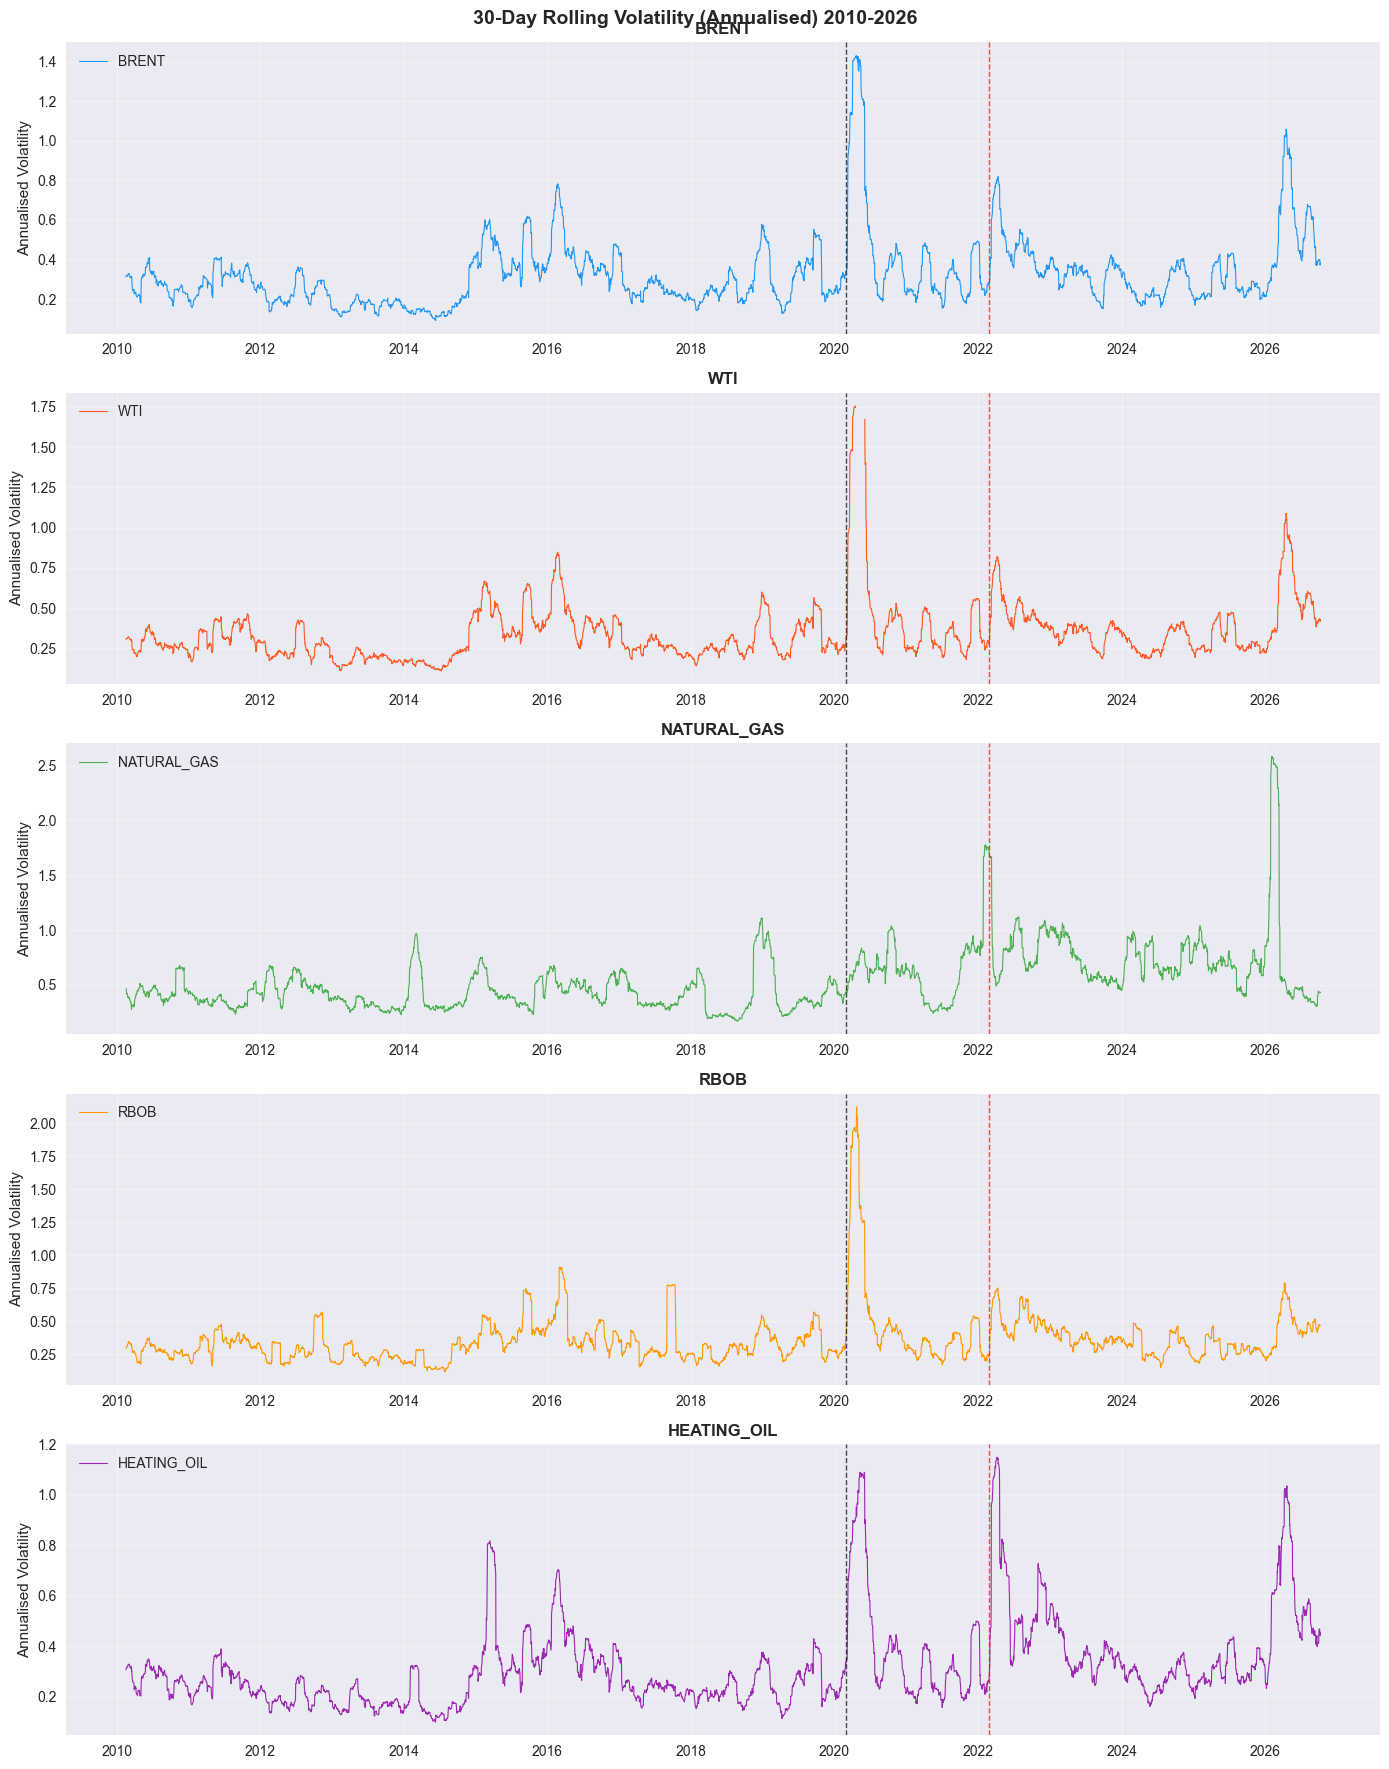

Chart saved!


In [8]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))
fig.suptitle('30-Day Rolling Volatility (Annualised) 2010-2026',
             fontsize=14, fontweight='bold')

colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

for idx, (name, color) in enumerate(zip(commodities, colors)):
    ax = axes[idx]
    returns = data[name]['Log_Return']
    
    # Rolling 30 day volatility, annualised
    # Multiply by sqrt(252) to annualise
    # 252 = number of trading days in a year
    rolling_vol = returns.rolling(window=30).std() * np.sqrt(252)
    
    ax.plot(rolling_vol.index, rolling_vol, 
            color=color, linewidth=0.8, label=name)
    
    # Mark major events
    ax.axvline(pd.Timestamp('2020-03-01'), color='black',
               linestyle='--', alpha=0.7, linewidth=1)
    ax.axvline(pd.Timestamp('2022-02-24'), color='red',
               linestyle='--', alpha=0.7, linewidth=1)
    
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Annualised Volatility')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Part 4 — Correlation Analysis
We examine how closely commodities move together using:
1. Correlation matrix of closing prices
2. Correlation matrix of log returns
3. Rolling 90-day correlation between BRENT and WTI

Note: Price correlation and return correlation tell different stories.
Price correlation can be misleading due to shared trends.
Return correlation is more meaningful for trading.

In [9]:
price_df = pd.DataFrame()

for name in commodities:
    price_df[name] = data[name]['Close']

# Step 2 — Build a combined dataframe of log returns
returns_df = pd.DataFrame()

for name in commodities:
    returns_df[name] = data[name]['Log_Return']

print("Combined price dataframe shape:", price_df.shape)
print("Combined returns dataframe shape:", returns_df.shape)
print("\nFirst 5 rows of price dataframe:")
print(price_df.head())

Combined price dataframe shape: (4186, 5)
Combined returns dataframe shape: (4186, 5)

First 5 rows of price dataframe:
                BRENT        WTI  NATURAL_GAS    RBOB  HEATING_OIL
Date                                                              
2010-01-04  80.120003  81.510002        5.884  2.1044       2.1905
2010-01-05  80.589996  81.769997        5.637  2.1250       2.1941
2010-01-06  81.889999  83.180000        6.009  2.1366       2.2032
2010-01-07  81.510002  82.660004        5.806  2.1349       2.1836
2010-01-08  81.370003  82.750000        5.749  2.1553       2.2003


## Correlation Heatmaps
We plot two heatmaps:
1. Price correlation — how raw prices move together
2. Return correlation — how daily moves are related (more meaningful)

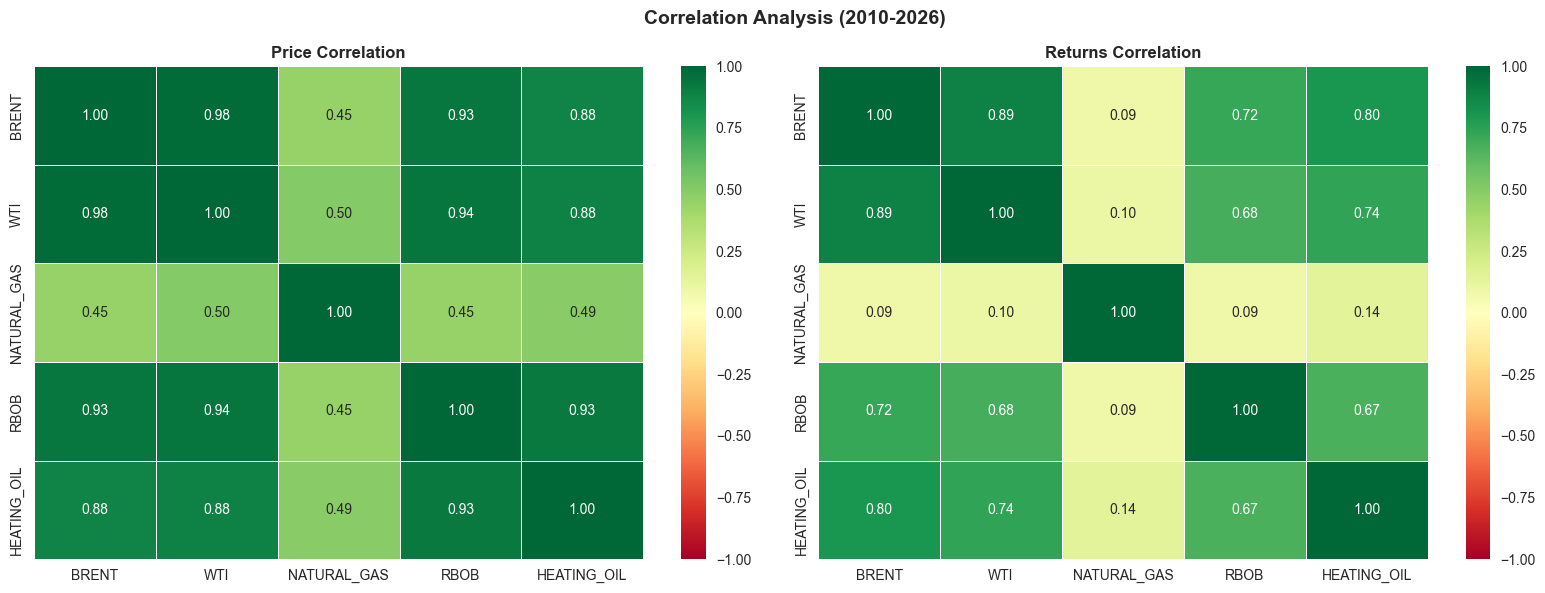

Chart saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Analysis (2010-2026)', 
             fontsize=14, fontweight='bold')

# Heatmap 1 — Price Correlation
price_corr = price_df.corr()
sns.heatmap(price_corr, 
            annot=True,          # show numbers inside boxes
            fmt='.2f',           # 2 decimal places
            cmap='RdYlGn',       # red=negative, yellow=neutral, green=positive
            vmin=-1, vmax=1,     # fix scale from -1 to 1
            ax=axes[0],
            linewidths=0.5)
axes[0].set_title('Price Correlation', fontweight='bold')

# Heatmap 2 — Returns Correlation
returns_corr = returns_df.corr()
sns.heatmap(returns_corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            vmin=-1, vmax=1,
            ax=axes[1],
            linewidths=0.5)
axes[1].set_title('Returns Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig('data/correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Rolling Correlation — BRENT vs WTI
90-day rolling correlation shows how the BRENT-WTI relationship
changed over time, especially during market stress periods.

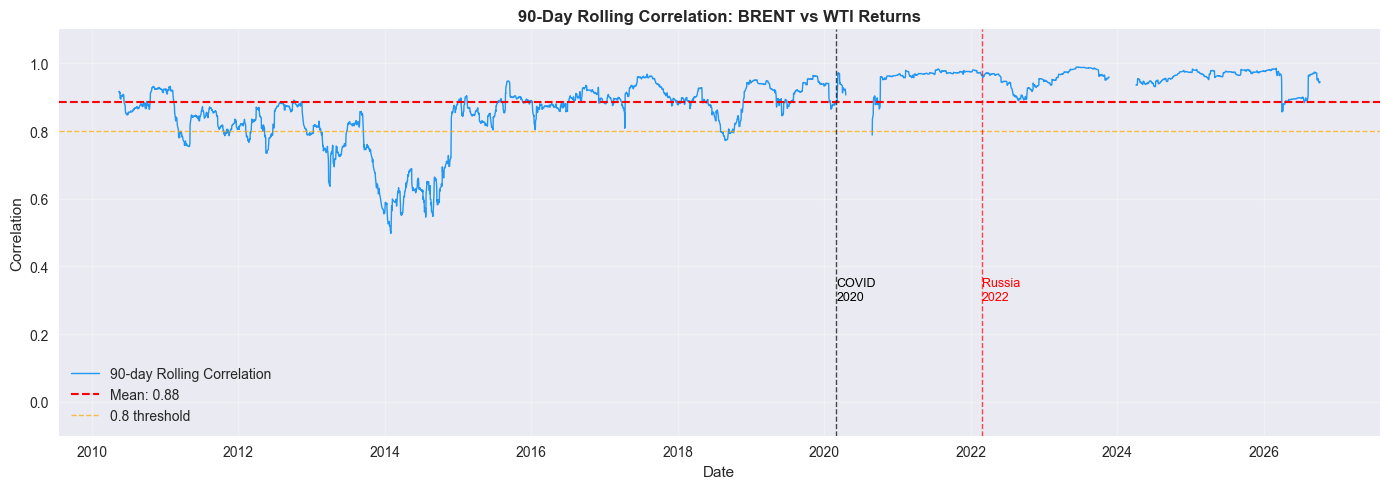

Chart saved!


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

# Calculate 90 day rolling correlation between BRENT and WTI returns
rolling_corr = returns_df['BRENT'].rolling(window=90).corr(returns_df['WTI'])

ax.plot(rolling_corr.index, rolling_corr, 
        color='#2196F3', linewidth=1, label='90-day Rolling Correlation')

# Add reference lines
ax.axhline(y=rolling_corr.mean(), color='red', linestyle='--', 
           linewidth=1.5, label=f'Mean: {rolling_corr.mean():.2f}')
ax.axhline(y=0.8, color='orange', linestyle='--',
           linewidth=1, alpha=0.7, label='0.8 threshold')

# Mark major events
ax.axvline(pd.Timestamp('2020-03-01'), color='black',
           linestyle='--', alpha=0.7, linewidth=1)
ax.axvline(pd.Timestamp('2022-02-24'), color='red',
           linestyle='--', alpha=0.7, linewidth=1)

ax.text(pd.Timestamp('2020-03-01'), 0.3, 'COVID\n2020', 
        fontsize=9, color='black')
ax.text(pd.Timestamp('2022-02-24'), 0.3, 'Russia\n2022',
        fontsize=9, color='red')

ax.set_title('90-Day Rolling Correlation: BRENT vs WTI Returns', 
             fontweight='bold')
ax.set_ylabel('Correlation')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('data/rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Part 5 — Stationarity Testing
We test whether price series and return series are stationary.
Stationarity is a requirement for SARIMA modelling.
We use two complementary tests:
- ADF (Augmented Dickey Fuller) — proves stationarity
- KPSS — proves non-stationarity
Rule: p-value < 0.05 means result is statistically significant

In [12]:
def test_stationarity(series, name, series_type):
    """
    Runs ADF and KPSS tests on a series and prints results cleanly
    """
    # Drop missing values before testing
    series = series.dropna()
    
    # ADF Test
    adf_result = adfuller(series)
    adf_pvalue = adf_result[1]
    
    # KPSS Test
    kpss_result = kpss(series, regression='c')
    kpss_pvalue = kpss_result[1]
    
    # Interpret results
    adf_conclusion = "Stationary ✅" if adf_pvalue < 0.05 else "Non-Stationary ❌"
    kpss_conclusion = "Stationary ✅" if kpss_pvalue > 0.05 else "Non-Stationary ❌"
    
    # Final verdict
    if adf_pvalue < 0.05 and kpss_pvalue > 0.05:
        verdict = "STATIONARY ✅"
    elif adf_pvalue > 0.05 and kpss_pvalue < 0.05:
        verdict = "NON-STATIONARY ❌"
    else:
        verdict = "UNCLEAR ⚠️"
    
    print(f"\n  {name} — {series_type}")
    print(f"  ADF  p-value : {adf_pvalue:.4f} → {adf_conclusion}")
    print(f"  KPSS p-value : {kpss_pvalue:.4f} → {kpss_conclusion}")
    print(f"  VERDICT      : {verdict}")

# Test prices and returns for all commodities
print("=" * 60)
print("STATIONARITY TEST RESULTS")
print("=" * 60)

for name in commodities:
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    
    # Test closing prices
    test_stationarity(data[name]['Close'], name, 'Closing Price')
    
    # Test log returns
    test_stationarity(data[name]['Log_Return'], name, 'Log Returns')

STATIONARITY TEST RESULTS

──────────────────────────────────────────────────
  BRENT
──────────────────────────────────────────────────

  BRENT — Closing Price
  ADF  p-value : 0.2477 → Non-Stationary ❌
  KPSS p-value : 0.0100 → Non-Stationary ❌
  VERDICT      : NON-STATIONARY ❌

  BRENT — Log Returns
  ADF  p-value : 0.0000 → Stationary ✅
  KPSS p-value : 0.1000 → Stationary ✅
  VERDICT      : STATIONARY ✅

──────────────────────────────────────────────────
  WTI
──────────────────────────────────────────────────

  WTI — Closing Price
  ADF  p-value : 0.1063 → Non-Stationary ❌
  KPSS p-value : 0.0100 → Non-Stationary ❌
  VERDICT      : NON-STATIONARY ❌

  WTI — Log Returns
  ADF  p-value : 0.0000 → Stationary ✅
  KPSS p-value : 0.1000 → Stationary ✅
  VERDICT      : STATIONARY ✅

──────────────────────────────────────────────────
  NATURAL_GAS
──────────────────────────────────────────────────

  NATURAL_GAS — Closing Price
  ADF  p-value : 0.0050 → Stationary ✅
  KPSS p-value : 0.

## Part 6 — Seasonal Decomposition
We decompose each commodity's price series into:
- Trend: long term price direction
- Seasonality: repeating annual patterns
- Residual: random noise after removing trend and seasonality

This directly informs seasonal adjustments in our SARIMA and Prophet models.

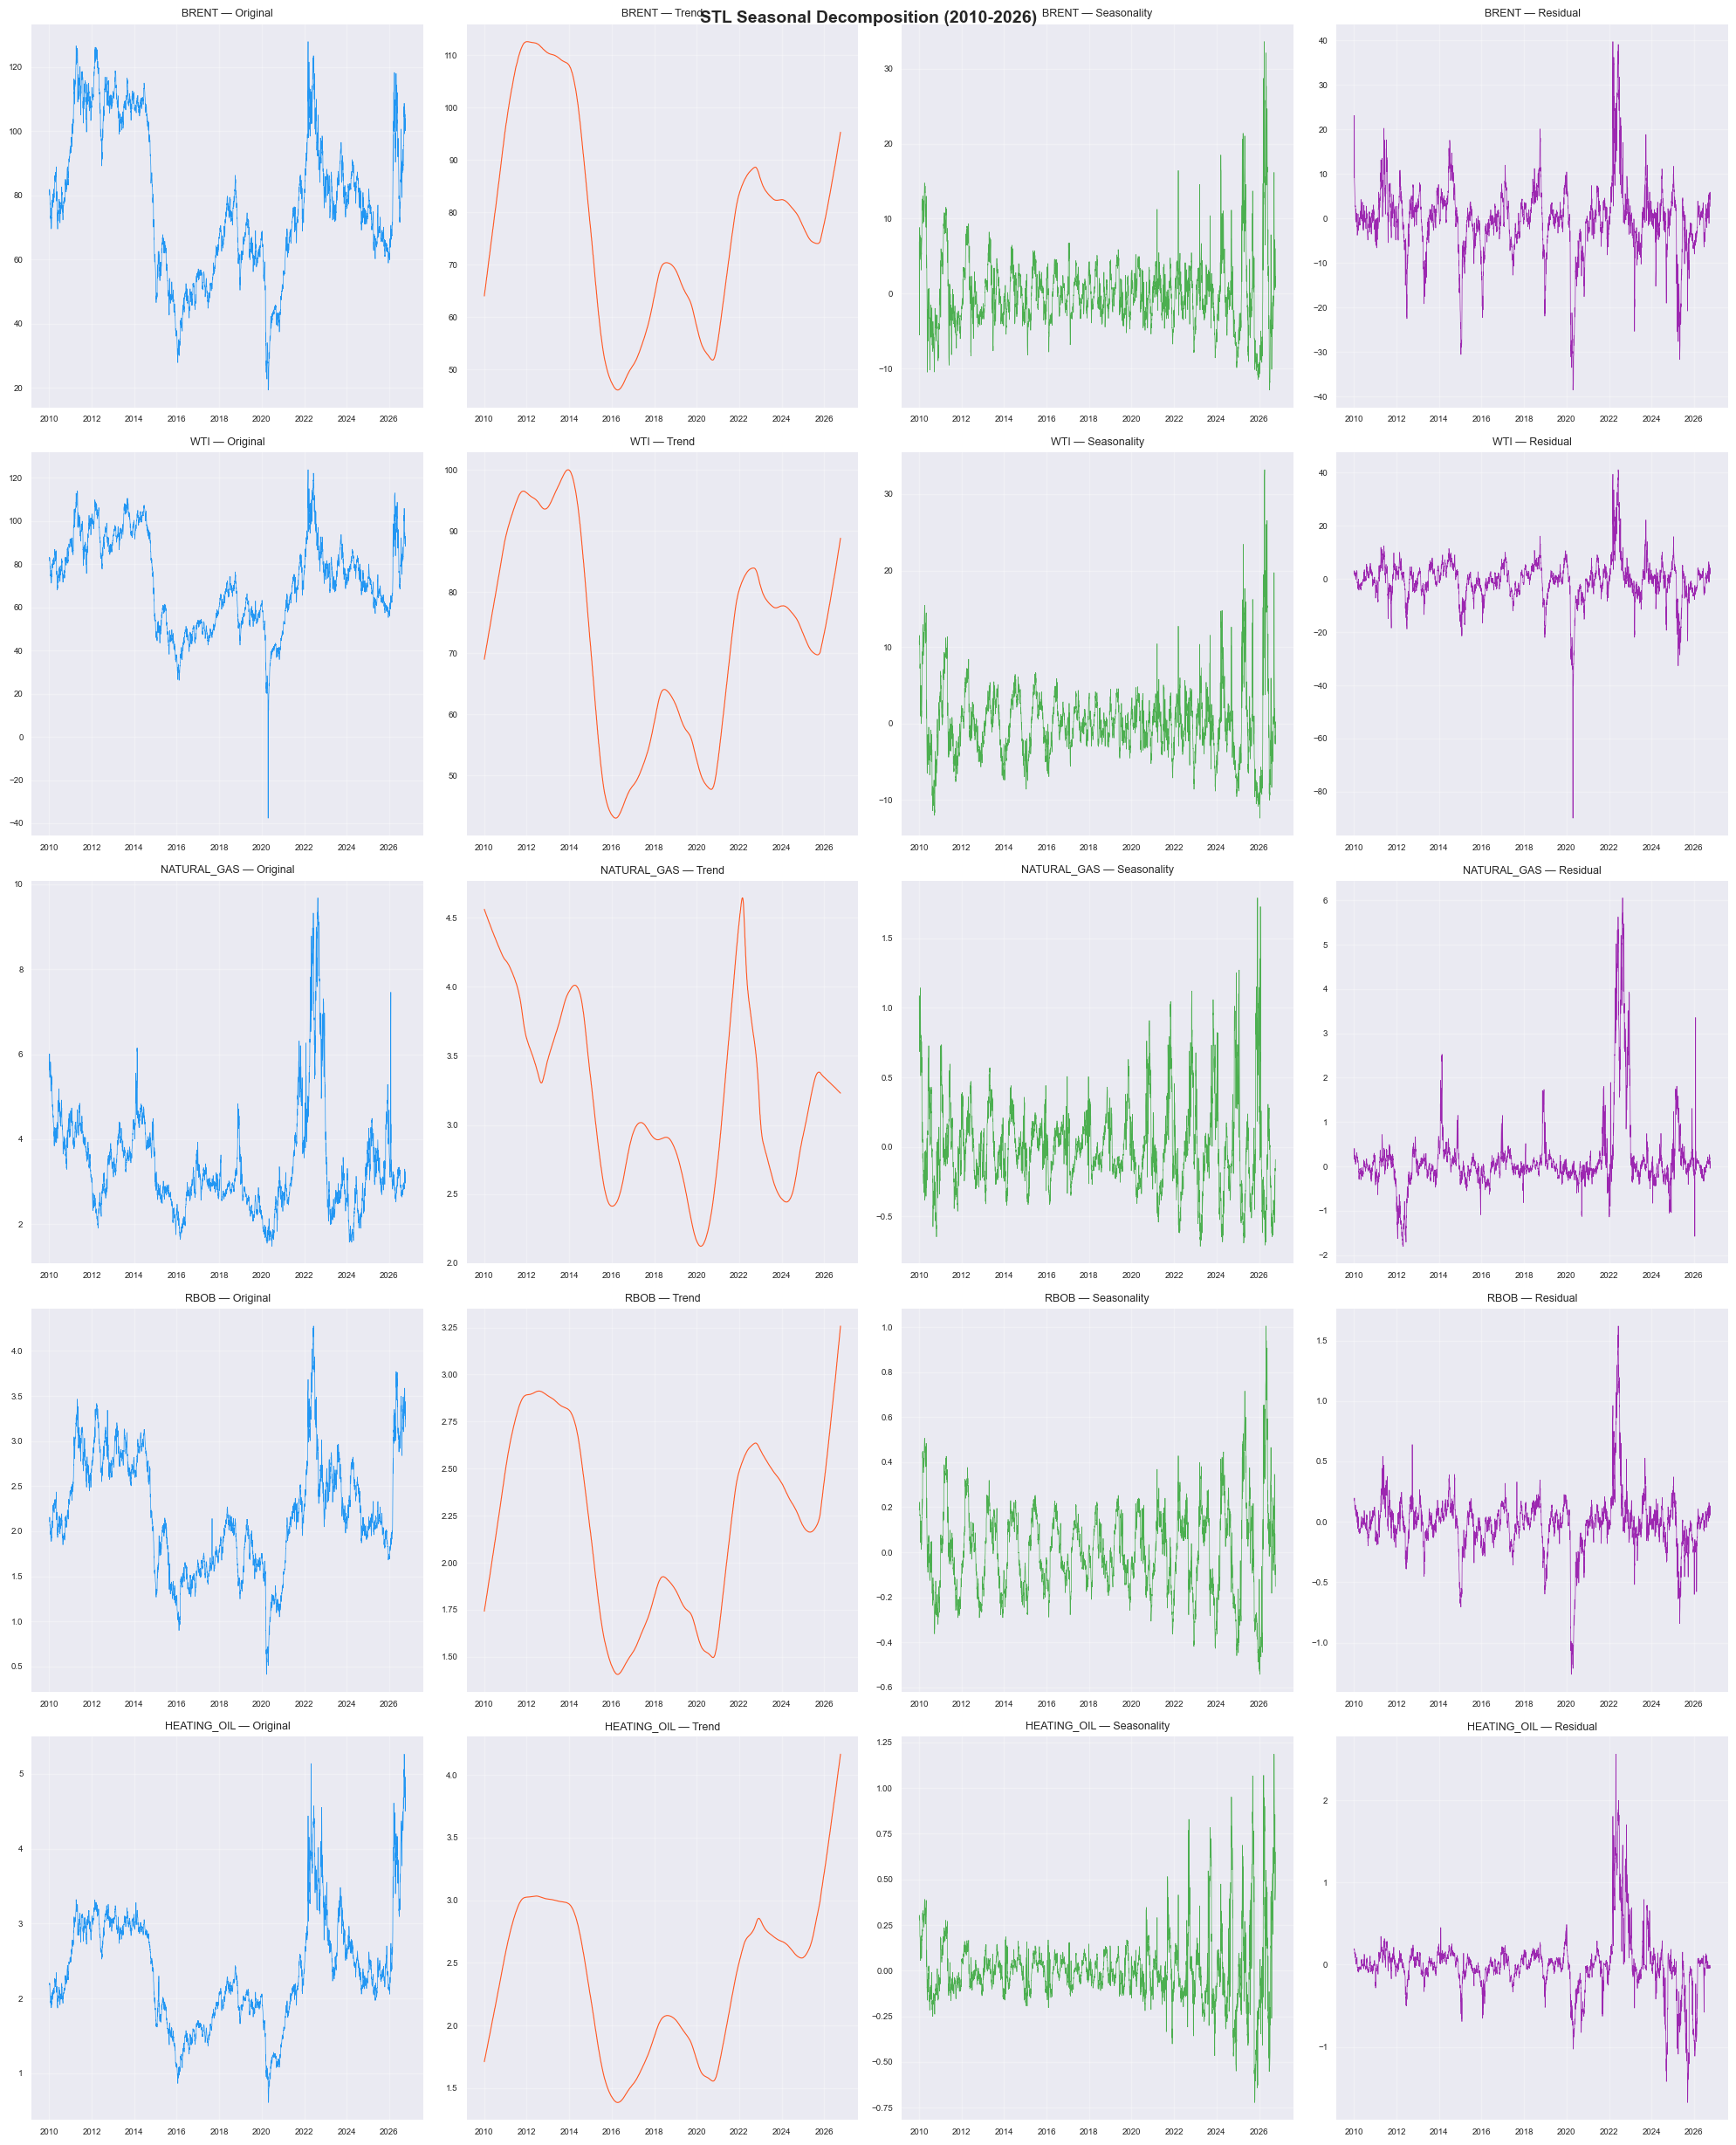

Chart saved!


In [13]:
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
fig.suptitle('STL Seasonal Decomposition (2010-2026)',
             fontsize=14, fontweight='bold')

for idx, name in enumerate(commodities):
    # Get closing price, drop missing values
    close = data[name]['Close'].dropna()
    
    # STL decomposition
    # period=252 means annual seasonality (252 trading days = 1 year)
    stl = STL(close, period=252, robust=True)
    result = stl.fit()
    
    # Plot original, trend, seasonal, residual
    axes[idx, 0].plot(close.index, close, 
                      color='#2196F3', linewidth=0.5)
    axes[idx, 0].set_title(f'{name} — Original', fontsize=9)
    
    axes[idx, 1].plot(result.trend.index, result.trend,
                      color='#FF5722', linewidth=0.8)
    axes[idx, 1].set_title(f'{name} — Trend', fontsize=9)
    
    axes[idx, 2].plot(result.seasonal.index, result.seasonal,
                      color='#4CAF50', linewidth=0.5)
    axes[idx, 2].set_title(f'{name} — Seasonality', fontsize=9)
    
    axes[idx, 3].plot(result.resid.index, result.resid,
                      color='#9C27B0', linewidth=0.5)
    axes[idx, 3].set_title(f'{name} — Residual', fontsize=9)
    
    # Add grid to all subplots
    for ax in axes[idx]:
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('data/seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Seasonal Pattern — Zoomed View (2020-2023)
Zooming into 3 years makes seasonal patterns clearly visible.
We focus on Heating Oil and Natural Gas which have strongest seasonality.

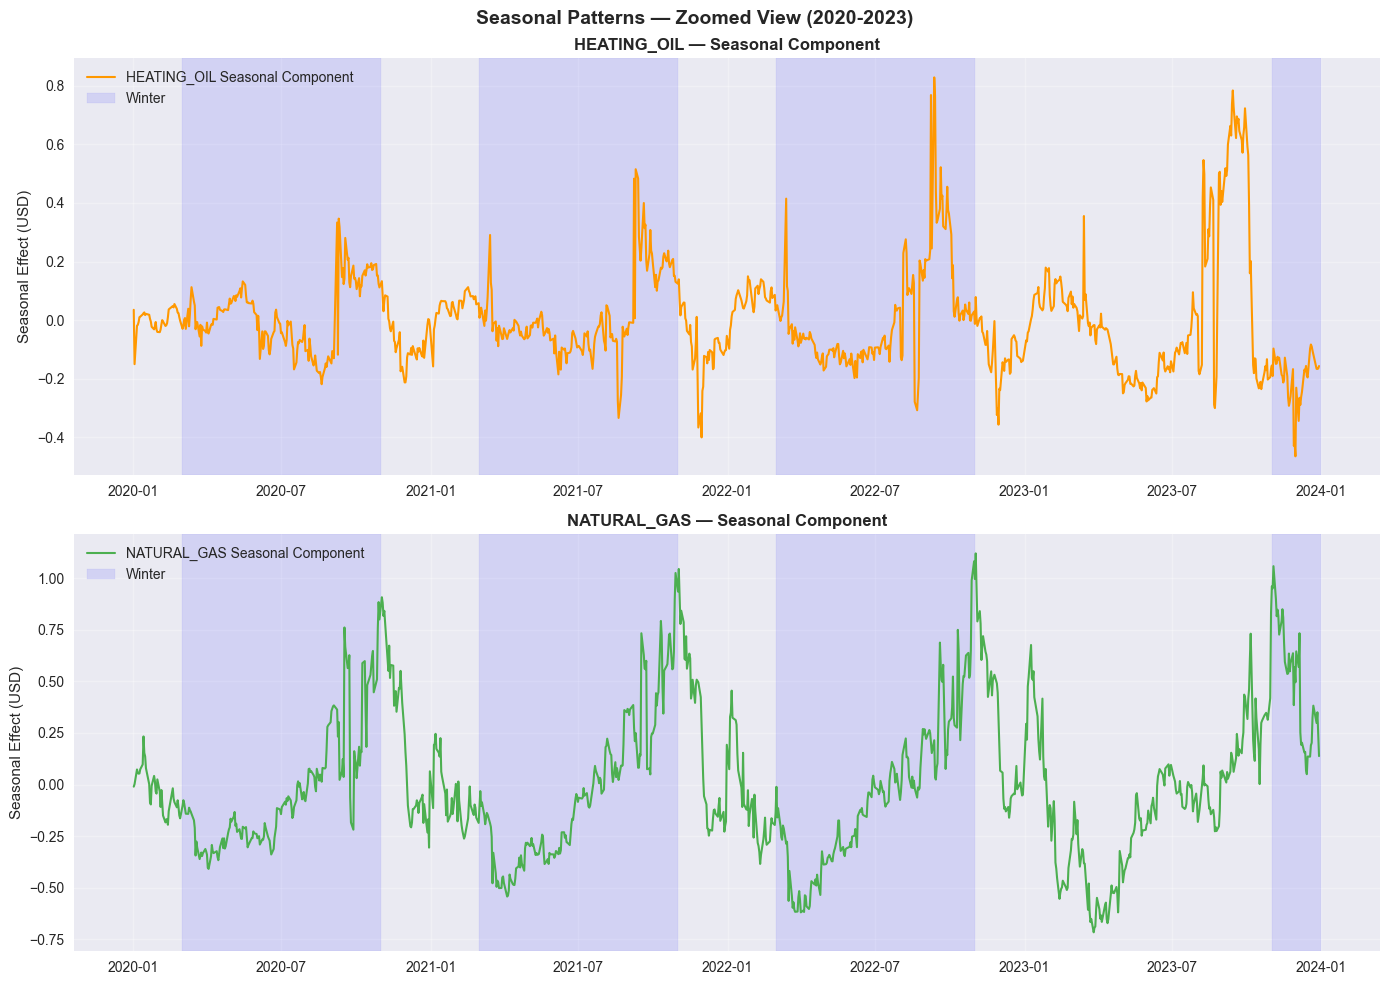

Chart saved!


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Seasonal Patterns — Zoomed View (2020-2023)',
             fontsize=14, fontweight='bold')

focus_commodities = ['HEATING_OIL', 'NATURAL_GAS']
colors = ['#FF9800', '#4CAF50']

for idx, (name, color) in enumerate(zip(focus_commodities, colors)):
    ax = axes[idx]
    
    # Get closing price
    close = data[name]['Close'].dropna()
    
    # STL decomposition
    stl = STL(close, period=252, robust=True)
    result = stl.fit()
    
    # Zoom into 2020-2023 only
    mask = (result.seasonal.index >= '2020-01-01') & \
           (result.seasonal.index <= '2023-12-31')
    
    seasonal_zoomed = result.seasonal[mask]
    
    ax.plot(seasonal_zoomed.index, seasonal_zoomed,
            color=color, linewidth=1.5, label=f'{name} Seasonal Component')
    
    # Mark winter periods
    for year in [2020, 2021, 2022, 2023]:
        ax.axvspan(pd.Timestamp(f'{year}-11-01'),
                   pd.Timestamp(f'{year}-03-01') if year < 2023 
                   else pd.Timestamp('2023-12-31'),
                   alpha=0.1, color='blue', label='Winter' if year == 2020 else '')
    
    ax.set_title(f'{name} — Seasonal Component', fontweight='bold')
    ax.set_ylabel('Seasonal Effect (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/seasonal_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## EDA Summary — Key Findings

### 1. Price Distribution
- BRENT trades between $19 and $128 over 15 years, mean $78
- WTI recorded negative prices (-$37) in April 2020 — historic contango blowout
- Natural Gas operates at a completely different price scale ($1.5 to $9)

### 2. Returns & Volatility
- Natural Gas is the most volatile commodity — weather driven demand
- All oil commodities showed volatility spike during COVID March 2020
- Natural Gas volatility spiked in late 2022 — European energy crisis

### 3. Correlation
- BRENT and WTI highly correlated (returns: 0.89) — same crude oil market
- Natural Gas weakly correlated with all others — different demand drivers
- Correlation broke down during 2014-15 Saudi price war and COVID 2020

### 4. Stationarity
- Closing prices → Non-Stationary ❌ (trending over time)
- Log Returns → Stationary ✅ (fluctuate around zero)
- Implication: SARIMA needs log returns, Prophet can use raw prices

### 5. Seasonality
- Heating Oil → single winter seasonality (Oct-Feb demand peak)
- Natural Gas → dual seasonality (summer AC + winter heating)
- These patterns will be explicitly modelled in Prophet